## Implement Transfer Learning for Image Classification using pre-trained model

In [9]:
!pip install --upgrade tensorflow-datasets

In [16]:
import os
import tarfile
import urllib.request
import pathlib
import tensorflow as tf
import tensorflow_datasets as tfds
import matplotlib.pyplot as plt

In [17]:
print("Starting manual download from Google's servers...")
dataset_url = "https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz"

# local storage paths
cache_dir = os.path.expanduser('~/.keras/datasets')
os.makedirs(cache_dir, exist_ok=True)
tgz_path = os.path.join(cache_dir, 'flower_photos.tgz')
extracted_dir = os.path.join(cache_dir, 'flower_photos')

# Download the archive file
if not os.path.exists(tgz_path):
    print("Downloading file (approx. 218 MB)... This might take a minute.")
    urllib.request.urlretrieve(dataset_url, tgz_path)
    print("Download finished!")

# Extract the tarball contents
if not os.path.exists(extracted_dir):
    print("Extracting files...")
    with tarfile.open(tgz_path, "r:gz") as tar:
        tar.extractall(path=cache_dir)
    print("Extraction completed!")

data_dir = pathlib.Path(extracted_dir)
print(f"\nDataset is safely ready at: {data_dir}")

# Architecture parameters
IMG_SIZE = 224   # MobileNetV2 standard input size
BATCH_SIZE = 32


Starting manual download from Google's servers...
Download finished!
Extracting files...


/tmp/ipykernel_1028/673211062.py:20: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(path=cache_dir)


Extraction completed!

Dataset is safely ready at: /root/.keras/datasets/flower_photos


In [18]:
print("\nCreating training data splits...")
train_dataset = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE
)

validation_dataset = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE
)

class_names = train_dataset.class_names
num_classes = len(class_names)
print(f"Target Flower Classes found: {class_names}")


Creating training data splits...
Found 3670 files belonging to 5 classes.
Using 2936 files for training.
Found 3670 files belonging to 5 classes.
Using 734 files for validation.
Target Flower Classes found: ['daisy', 'dandelion', 'roses', 'sunflowers', 'tulips']


In [22]:
def preprocess_images(image, label):
    # Resize images to match MobileNetV2 requirements
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))
    # MobileNetV2 expects pixel values scaled between -1 and 1
    image = tf.keras.applications.mobilenet_v2.preprocess_input(image)
    return image, label


In [23]:
AUTOTUNE = tf.data.AUTOTUNE
train_dataset = train_dataset.map(preprocess_images).cache().prefetch(buffer_size=AUTOTUNE)
validation_dataset = validation_dataset.map(preprocess_images).cache().prefetch(buffer_size=AUTOTUNE)

In [24]:
print("Building MobileNetV2 base model...")
# Load MobileNetV2 pre-trained on ImageNet.

base_model = tf.keras.applications.MobileNetV2(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    include_top=False,
    weights='imagenet'
)

# FREEZE THE BASE MODEL: This keeps the pre-trained ImageNet weights from changing
base_model.trainable = False

# Construct the final network architecture
model = tf.keras.Sequential([
    base_model,
    tf.keras.layers.GlobalAveragePooling2D(), # Reduces 2D features to a single vector
    tf.keras.layers.Dropout(0.2),              # Prevents overfitting
    tf.keras.layers.Dense(num_classes, activation='softmax') # Final output layer for flower types
])

Building MobileNetV2 base model...
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [25]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy', # Used because labels are integer numbers
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 5)              │         6,405 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,264,389 (8.64 MB)

 Trainable params: 6,405 (25.02 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [26]:
EPOCHS = 5
print(f"Starting training for {EPOCHS} epochs...")

history = model.fit(
    train_dataset,
    epochs=EPOCHS,
    validation_data=validation_dataset
)

Starting training for 5 epochs...
Epoch 1/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 56s 403ms/step - accuracy: 0.7238 - loss: 0.7528 - val_accuracy: 0.8501 - val_loss: 0.4244
Epoch 2/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 3s 36ms/step - accuracy: 0.8661 - loss: 0.4013 - val_accuracy: 0.8774 - val_loss: 0.3520
Epoch 3/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 3s 36ms/step - accuracy: 0.8896 - loss: 0.3236 - val_accuracy: 0.8937 - val_loss: 0.3237
Epoch 4/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 3s 38ms/step - accuracy: 0.9118 - loss: 0.2744 - val_accuracy: 0.8978 - val_loss: 0.3110
Epoch 5/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 5s 36ms/step - accuracy: 0.9220 - loss: 0.2387 - val_accuracy: 0.8951 - val_loss: 0.2989


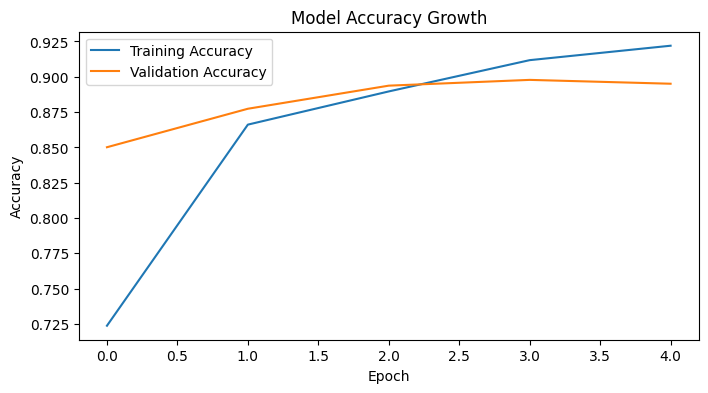

In [28]:
plt.figure(figsize=(8, 4))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy Growth')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step


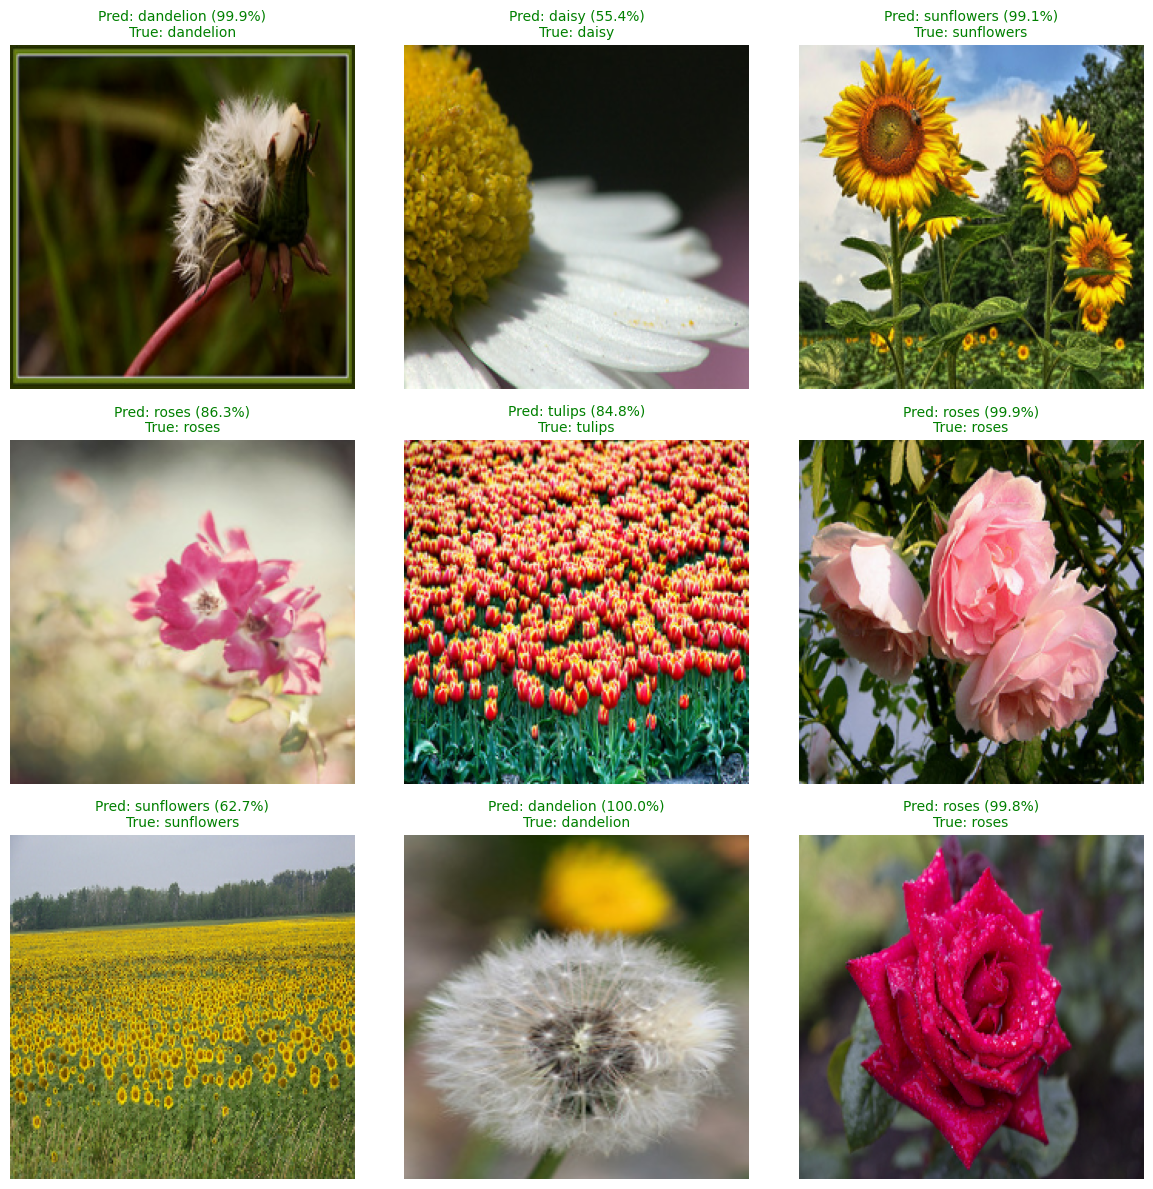

In [29]:
import numpy as np
import matplotlib.pyplot as plt

image_batch, label_batch = next(iter(validation_dataset))
predictions = model.predict(image_batch)


plt.figure(figsize=(12, 12))
for i in range(9):
    ax = plt.subplot(3, 3, i + 1)

    # Re-scale the image values from [-1, 1] back to [0, 1]
    display_img = (image_batch[i] + 1.0) / 2.0
    display_img = np.clip(display_img, 0.0, 1.0)
    plt.imshow(display_img)

    #  Determine predicted class and confidence
    predicted_label_idx = np.argmax(predictions[i])
    predicted_name = class_names[predicted_label_idx]
    confidence = predictions[i][predicted_label_idx] * 100

    # Determine the actual true label
    true_label_idx = int(label_batch[i])
    true_name = class_names[true_label_idx]

    # Color code the title: Green for correct, Red for wrong
    if predicted_label_idx == true_label_idx:
        title_color = 'green'
        title_text = f"Pred: {predicted_name} ({confidence:.1f}%)\nTrue: {true_name}"
    else:
        title_color = 'red'
        title_text = f"Pred: {predicted_name} ({confidence:.1f}%)\nTrue: {true_name}"

    plt.title(title_text, color=title_color, fontsize=10)
    plt.axis("off")

plt.tight_layout()
plt.show()


### Make a prediction on a new image

Saving photo-1565573349860-cbf26ef3f40f.avif to photo-1565573349860-cbf26ef3f40f.avif
1/1 ━━━━━━━━━━━━━━━━━━━━ 15s 15s/step


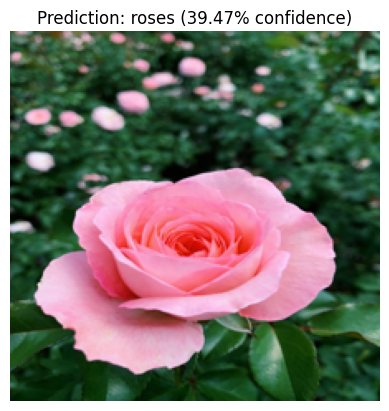

In [30]:
from google.colab import files
from PIL import Image
import io

# Upload a new image
uploaded = files.upload()

for fn in uploaded.keys():
    # Read the image from bytes
    img = Image.open(io.BytesIO(uploaded[fn]))

    # Convert to RGB if not already (some images might be RGBA or grayscale)
    if img.mode != 'RGB':
        img = img.convert('RGB')

    # Resize to the model's expected input size
    img = img.resize((IMG_SIZE, IMG_SIZE))

    # Convert to numpy array and add batch dimension
    img_array = tf.keras.preprocessing.image.img_to_array(img)
    img_array = tf.expand_dims(img_array, 0)  # Create a batch

    # Preprocess the image using the same function as during training
    processed_img_array, _ = preprocess_images(img_array, tf.constant(0)) # label is dummy here

    # Make prediction
    predictions = model.predict(processed_img_array)
    score = tf.nn.softmax(predictions[0])

    # Display the image and prediction
    plt.imshow(img) # Display original image
    plt.axis('off')
    plt.title(f"Prediction: {class_names[np.argmax(score)]} ({100 * np.max(score):.2f}% confidence)")
    plt.show()
